# ROC 곡선
* ROC 곡선과 이에 기반한 AUC 스코어 : 이진 분류의 예측 성능 측정에서 중요 지표임
* ROC 곡선 (Receiver Operation Characteristic Curve) : 수신자 판단 곡선
  * 의학 분야에서도 많이 사용되나, 머신러닝 이진 분류 모델의 예측 성능 판단에서 중요 평가지표
  * FPR(False Positive Rate)이 변할 때 TPR(True Positive Rate)이 어떻게 변하는지 나타냄
    * X축=FPR, Y축=TPR
    * 민감도(TPR) : 재현율. TPR = TP/(FN+TP). 실제값 positive(양성)가 정확히 예측돼야 하는 수준. 질병 있는 사람을 아프다고 양성판정
    * 특이성(specificity, TNR) : TNR(True Negative Rate)=TN/(FP+TN), 민감도에 대응하는 지표, 실제값 negative(음성)가 정확히 예측돼야 하는 수준, 건강한 사람을 건강하다고 음성 판정
    * X축인 FPR = FP/(FP+TN) = 1 - TNR = 1 - 특이성
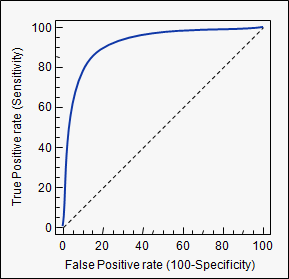
* 가운데 직선은 ROC 곡선의 최저값. 랜덤 수준의 이진 분류의 ROC 직선. AUC=0.5 -> 가운데 직선에 ROC 곡선이 가까울 수록 성능 떨어지는 것
* FPR을 0~1까지 변경하며 TPR의 변화값 구함
  * FPR을 변경하는 방법 : 분류 결정 임곗값(positive 에측값을 결정하는 확률의 기준)을 변경하는 것
    * FPR을 0으로 만들려면? 임곗값=1로 -> Positive 예측 기준이 매우 높아 분류기(classifier)가 임곗값보다 높은 확률 가진 데이터를 positive로 예측할 수 없음 -> FP=0 -> FPR=0
    * FPR을 1으로 만들려면? 임곗값=0로 -> Negative 예측이 없음 -> TN=0 -> FPR=1
* 따라서 ROC 곡선은 임곗값을 1부터 0까지 거꾸로 변화시키며 구한 재현율 곡선의 형태와 비슷

# 사이킷런의 ROC 곡선
* roc_curve() API
  * precision_recall_curve() API와 사용법 유사 <-> 반환값 구성이 다름
  * 입력 파라미터
    * y_true = 실제 클래스값 array, 형상=[데이터 건수]
    * y_score = predict_proba()의 반환값 배열에서 positive 칼럼의 에측 확률이 보통 사용됨, 형상=[n_smaples]
  * 반환값
    * fpr = fpr을 배열로 반환
    * tpr = tpr을 배열로 반환
    * thresholds = threshold 배열

In [5]:
### 2.6. 참고

from sklearn.preprocessing import LabelEncoder

# Null 처리 함수
def fillna(df):
    df['Age'].fillna(df['Age'].mean(), inplace=True)
    df['Cabin'].fillna('N', inplace=True)
    df['Embarked'].fillna('N', inplace=True)
    df['Fare'].fillna(0, inplace=True)
    return df

# 머신러닝 알고리즘에 불필요한 속성 제거
def drop_features(df):
    df.drop(['PassengerId', 'Name', 'Ticket'], axis=1, inplace=True)
    return df

# 레이블 인코딩 수행
def format_features(df):
    df['Cabin']=df['Cabin'].str[:1]
    features = ['Cabin', 'Sex', 'Embarked']
    for feature in features:
        le = LabelEncoder()
        le = le.fit(df[feature])
        df[feature] = le.transform(df[feature])
    return df

# 앞에서 설정한 데이터 전처리 함수 호출
def transform_features(df):
    df = fillna(df)
    df = drop_features(df)
    df = format_features(df)
    return df

In [6]:
# 로지스틱 회귀 기반으로 타이타닉 생존자 예측하고 평가 수행
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression

titanic_df = pd.read_csv(r'../kaggle/titanic/titanic_train.csv')
y_titanic_df = titanic_df['Survived']
x_titanic_df = titanic_df.drop('Survived', axis=1)
x_titanic_df = transform_features(x_titanic_df)

x_train, x_test, y_train, y_test = train_test_split(x_titanic_df, y_titanic_df, test_size=0.2, random_state=11)

lr_clf = LogisticRegression()
lr_clf.fit(x_train, y_train)

C:\Users\lumos\anaconda3\lib\site-packages\sklearn\linear_model\_logistic.py:762: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


LogisticRegression()

In [7]:
from sklearn.metrics import roc_curve

#레이블값이 1일떄의 예측 확률을 추출
pred_proba_class1 = lr_clf.predict_proba(x_test)[:, 1]

fprs, tprs, thresholds = roc_curve(y_test, pred_proba_class1)
#반환된 임곗값 배열에서 샘플로 데이터 추출하되, 임곗값을 5 step으로 추출
#thresholds[0]은 max(예측확률)+1로 임의 설정됨. 이를 제외하기 위해 np.arange를 1로 시작
thr_index = np.arange(1, thresholds.shape[0], 5)
print('샘플 추출을 위한 임곗값 배열의 index : ', thr_index)
print('샘플 index로 추출한 임곗값 : ', np.round(thresholds[thr_index], 2))

#5step 단위로 추출된 임곗값에 따른 FPR, TPR 값
print('샘플 임곗값 별 FPR : ', np.round(fprs[thr_index], 3))
print('샘플 임곗값 별 TPR : ', np.round(tprs[thr_index], 3))

샘플 추출을 위한 임곗값 배열의 index :  [ 1  6 11 16 21 26 31 36 41 46 51]
샘플 index로 추출한 임곗값 :  [0.97 0.65 0.63 0.56 0.45 0.38 0.31 0.13 0.12 0.11 0.1 ]
샘플 임곗값 별 FPR :  [0.    0.017 0.034 0.076 0.127 0.186 0.237 0.576 0.619 0.754 0.814]
샘플 임곗값 별 TPR :  [0.033 0.639 0.705 0.754 0.803 0.852 0.902 0.902 0.951 0.967 1.   ]


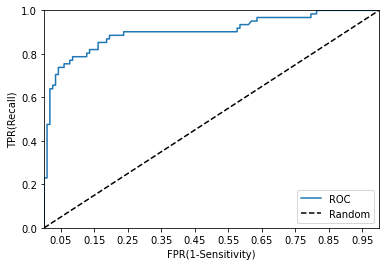

In [12]:
import matplotlib.pyplot as plt

# ROC 곡선 시각화
def roc_curve_plot(y_test, pred_proba_class1):
    fprs, tprs, thresholds = roc_curve(y_test, pred_proba_class1)
    plt.plot(fprs, tprs, label="ROC")
    plt.plot([0, 1], [0, 1], 'k--', label="Random")
    
    start, end = plt.xlim()
    plt.xticks(np.round(np.arange(start, end, 0.1), 2))
    plt.xlim(0, 1); plt.ylim(0, 1)
    plt.xlabel('FPR(1-Sensitivity)'); plt.ylabel('TPR(Recall)')
    plt.legend()
    
roc_curve_plot(y_test, pred_proba_class1)

# AUC 스코어
* ROC와 AUC
  * ROC 곡선 : FPR, TPR의 변화값을 보는 데 ㅣㅇ용
  * AUC 값 : 분류 성능의 지표로 사용. ROC 곡선 면적에 기반
* AUC(Area Under Curve) : ROC 곡선의 밑 면적 구한 것. 1에 가까울수록 좋은 수치
* FPR이 작은 상태에서 얼마나 큰 TPR을 얻느냐가 AUC 수치 커지는 데 관건임
  * 가운데 직선에서 멀어지고, 좌상단 모서리로 가파르게 곡선 이동살 후록 직사각형 가까운 곡선 되어 면적=1에 가까워짐
  * 가운데 대각선 수준은 0.5이므로, 보통 분류는 0.5이상의 AUC 값 가짐

In [14]:
from sklearn.metrics import roc_auc_score

pred_proba = lr_clf.predict_proba(x_test)[:, 1]
roc_score = roc_auc_score(y_test, pred_proba)
print('ROC AUC 값 : {0:.4f}'.format(roc_score))

ROC AUC 값 : 0.9024


In [15]:
### get_clf_eval() 함수 수정

from sklearn.metrics import accuracy_score, precision_score, recall_score, confusion_matrix

def get_clf_eval(y_test, pred=None, pred_proba=None):
    confusion = confusion_matrix(y_test, pred)
    accuracy = accuracy_score(y_test, pred)
    precision = precision_score(y_test, pred)
    recall = recall_score(y_test, pred)
    f1 = f1_score(y_test, pred)
    roc_auc = roc_auc_score(y_test, pred_proba)
    
    print('오차행렬 : ')
    print(confusion)
    
    print('정확도 : {0:.4f} , 정밀도 : {1:.4f} , 재현율 : {2:.4f} , F1 : {3:.4f}, AUC : {4:.4f}'.format(accuracy, precision, recall, f1, roc_auc))